In [1]:
import sqlite3
import pandas as pd

# Path to your database
DB_PATH = "../data/churn.db"

# Connect to database
conn = sqlite3.connect(DB_PATH)

query = """
SELECT 
    c.customer_id, c.gender, c.senior_citizen, c.partner, c.dependents, c.tenure, c.churn,
    a.contract, a.paperless_billing, a.payment_method, a.monthly_charges, a.total_charges,
    s.phone_service, s.multiple_lines, s.internet_service, s.online_security,
    s.online_backup, s.device_protection, s.tech_support, s.streaming_tv,
    s.streaming_movies
FROM customers c
JOIN accounts a ON c.customer_id = a.customer_id
JOIN services s ON c.customer_id = s.customer_id;
"""

# Load final dataset into dataframe
df = pd.read_sql_query(query, conn)

df.head()


,customer_id,gender,senior_citizen,partner,dependents,tenure,churn,contract,paperless_billing,payment_method,...,total_charges,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,3668-QPYBK,Male,0,No,No,2,Yes,Month-to-month,Yes,Mailed check,...,108.15,Yes,No,DSL,Yes,Yes,No,No,No,No
1,9237-HQITU,Female,0,No,Yes,2,Yes,Month-to-month,Yes,Electronic check,...,151.65,Yes,No,Fiber optic,No,No,No,No,No,No
2,9305-CDSKC,Female,0,No,Yes,8,Yes,Month-to-month,Yes,Electronic check,...,820.50,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes
3,7892-POOKP,Female,0,Yes,Yes,28,Yes,Month-to-month,Yes,Electronic check,...,3046.05,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes
4,0280-XJGEX,Male,0,No,Yes,49,Yes,Month-to-month,Yes,Bank transfer (automatic),...,5036.30,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   churn              7043 non-null   object 
 7   contract           7043 non-null   object 
 8   paperless_billing  7043 non-null   object 
 9   payment_method     7043 non-null   object 
 10  monthly_charges    7043 non-null   float64
 11  total_charges      7043 non-null   float64
 12  phone_service      7043 non-null   object 
 13  multiple_lines     7043 non-null   object 
 14  internet_service   7043 non-null   object 
 15  online_security    7043 non-null   object 
 16  online_backup      7043 

In [3]:
df.describe()


,senior_citizen,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [4]:
df.isnull().sum()


customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
churn                0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
dtype: int64

In [5]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})


In [6]:
df['gender'] = df['gender'].str.strip().str.lower()
df['partner'] = df['partner'].str.strip().str.lower()
df['dependents'] = df['dependents'].str.strip().str.lower()


In [7]:
service_cols = [
    'phone_service','multiple_lines','internet_service','online_security',
    'online_backup','device_protection','tech_support','streaming_tv','streaming_movies'
]

for col in service_cols:
    df[col] = df[col].str.strip().str.lower()


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")


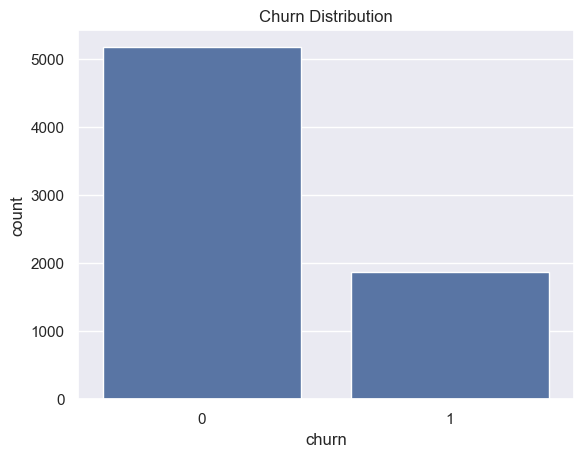

In [9]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()


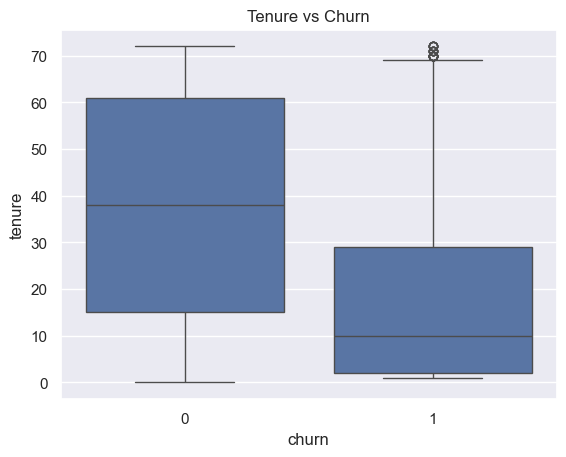

In [10]:
sns.boxplot(x='churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


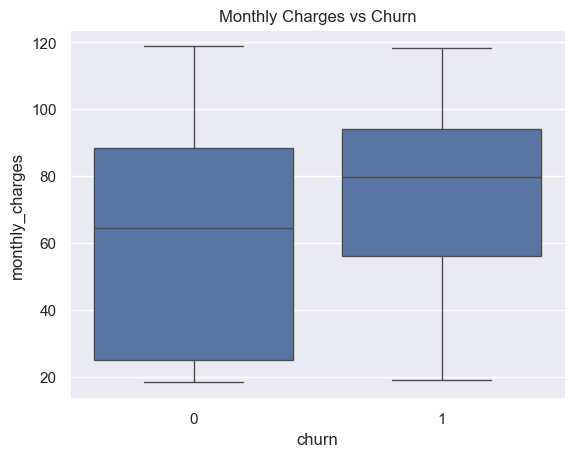

In [11]:
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


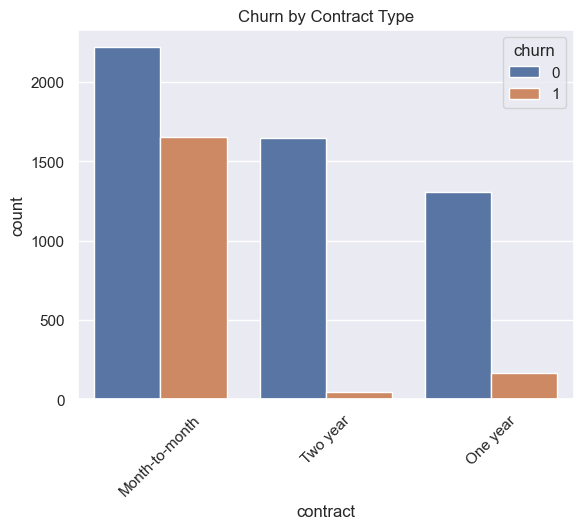

In [12]:
sns.countplot(x='contract', hue='churn', data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()



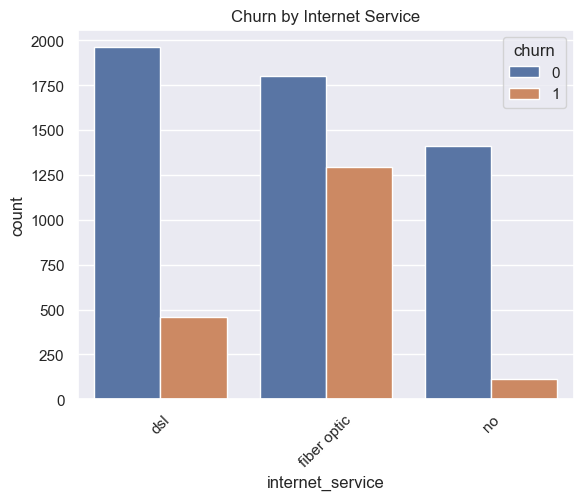

In [13]:
sns.countplot(x='internet_service', hue='churn', data=df)
plt.title("Churn by Internet Service")
plt.xticks(rotation=45)
plt.show()


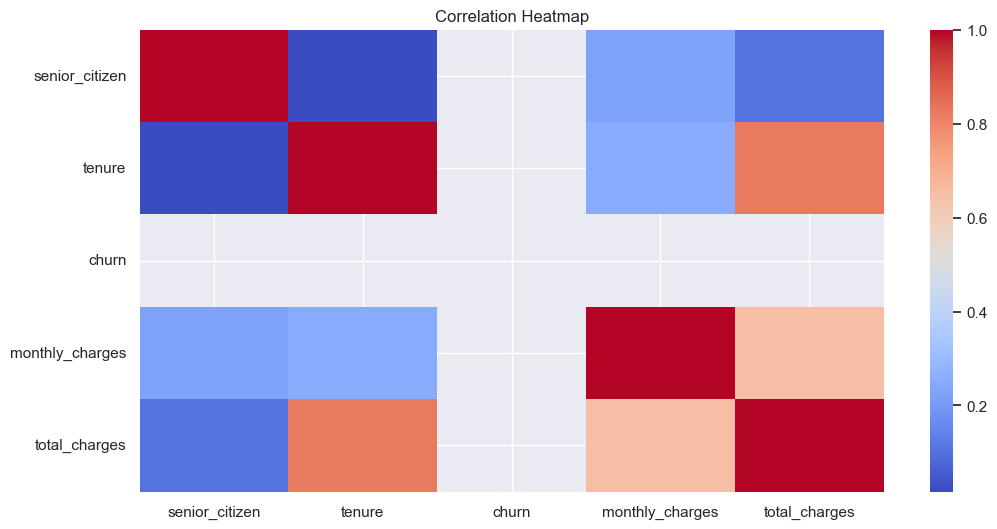

In [17]:
plt.figure(figsize=(12,6))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()




In [16]:
df['churn'] = df['churn'].map({'Yes':1, 'No':0})


In [19]:
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')


In [20]:
df[['monthly_charges', 'total_charges']].dtypes


monthly_charges    float64
total_charges      float64
dtype: object

In [21]:
df[['monthly_charges','total_charges']].isnull().sum()


monthly_charges    0
total_charges      0
dtype: int64

In [23]:
df['monthly_charges'].head(20)


0      53.85
1      70.70
2      99.65
3     104.80
4     103.70
5      55.20
6      39.65
7      20.15
8      99.35
9      30.20
10     64.70
11     69.70
12    106.35
13     97.85
14     80.65
15     99.10
16     80.65
17     95.45
18     94.40
19     79.35
Name: monthly_charges, dtype: float64

In [24]:
df['monthly_charges'] = df['monthly_charges'].astype(str).str.strip()


In [25]:
df['monthly_charges'] = df['monthly_charges'].str.replace('[^0-9\.]', '', regex=True)


In [26]:
df['monthly_charges'] = pd.to_numeric(df['monthly_charges'], errors='coerce')


In [27]:
df['monthly_charges'].fillna(df['monthly_charges'].median(), inplace=True)


C:\Users\Shivam Gupta\AppData\Local\Temp\ipykernel_12940\530684085.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['monthly_charges'].fillna(df['monthly_charges'].median(), inplace=True)


In [28]:
df['monthly_charges'].dtype


dtype('float64')

In [30]:
df['churn'].unique()


array([nan])

In [31]:
df_orig_churn_values = pd.read_sql_query("SELECT churn FROM customers LIMIT 20;", conn)
df_orig_churn_values


,churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
5,Yes
6,Yes
7,Yes
8,Yes
9,Yes


In [32]:
df_churn_raw = pd.read_sql_query("SELECT DISTINCT churn FROM customers;", conn)
df_churn_raw


,churn
0,Yes
1,No


In [33]:
# Reload the dataset fresh from SQL (to undo your accidental cleaning)
df = pd.read_sql_query(query, conn)


In [34]:
# Convert to string
df['churn'] = df['churn'].astype(str).str.strip()

# Just to inspect what exists
print(df['churn'].unique())


['Yes' 'No']


In [35]:
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})


In [36]:
df['churn'].unique()


array([1, 0])

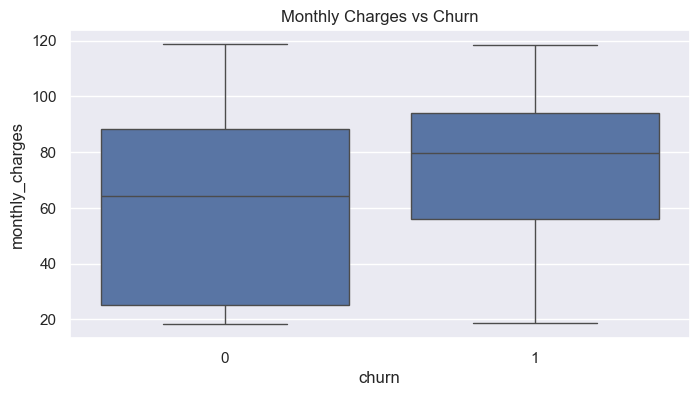

In [37]:
plt.figure(figsize=(8,4))
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


In [38]:
df_model = df.drop(columns=['customer_id'])


In [39]:
cat_cols = df_model.select_dtypes(include='object').columns

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)


In [40]:
from sklearn.model_selection import train_test_split

X = df_model.drop('churn', axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [41]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'monthly_charges', 'total_charges']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [43]:
X_train_resampled.shape, y_train_resampled.shape


((8278, 30), (8278,))